In [ ]:
# if using R directly
system("unzip -o /content/dataset.zip -d /content/data")
list.files("/content/data", recursive = TRUE)

character(0)

In [ ]:
list.files("/content")

[1] "BJP09192022.csv"                          
[2] "BJY09192022.csv"                          
[3] "centrality_measures.csv"                  
[4] "drive-download-20260902T060632Z-1-001.zip"
[5] "retweet_network.png"                      
[6] "sample_data"

In [ ]:
system("unzip -o /content/drive-download-20260902T060632Z-1-001.zip -d /content/data")
list.files("/content/data", recursive = TRUE)

[1] "c1.jpg" "c2.jpg" "c3.jpg" "c4.jpg" "c5.jpg" "c6.jpg" "p1.jpg" "p2.jpg"
 [9] "p3.jpg" "p4.jpg" "p5.jpg" "p6.jpg"

In [ ]:
"EBImage" %in% installed.packages()[,"Package"]

[1] TRUE

In [ ]:
library(reticulate)
py_require("tensorflow")

library(tensorflow)
library(keras)
tf_config()   # sanity check

TensorFlow v2.15.1 (~/.virtualenvs/r-tensorflow/lib/python3.10/site-packages/tensorflow)
Python v3.10 (~/.virtualenvs/r-tensorflow/bin/python)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'EBImage'”


TensorFlow v2.15.1 (~/.virtualenvs/r-tensorflow/lib/python3.10/site-packages/tensorflow)
Python v3.10 (~/.virtualenvs/r-tensorflow/bin/python)

[1] "c1.jpg" "c2.jpg" "c3.jpg" "c4.jpg" "c5.jpg" "c6.jpg" "p1.jpg" "p2.jpg"
 [9] "p3.jpg" "p4.jpg" "p5.jpg" "p6.jpg"

Model: "sequential"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 dense_2 (Dense)                    (None, 256)                     602368      
 dense_1 (Dense)                    (None, 128)                     32896       
 dense (Dense)                      (None, 2)                       258         
Total params: 635522 (2.42 MB)
Trainable params: 635522 (2.42 MB)
Non-trainable params: 0 (0.00 Byte)
________________________________________________________________________________


loss  accuracy 
0.2702194 0.9000000

         Actual
Predicted 0 1
        0 5 1
        1 0 4

loss    accuracy 
0.006935822 1.000000000

         Actual
Predicted 0 1
        0 1 0
        1 0 1

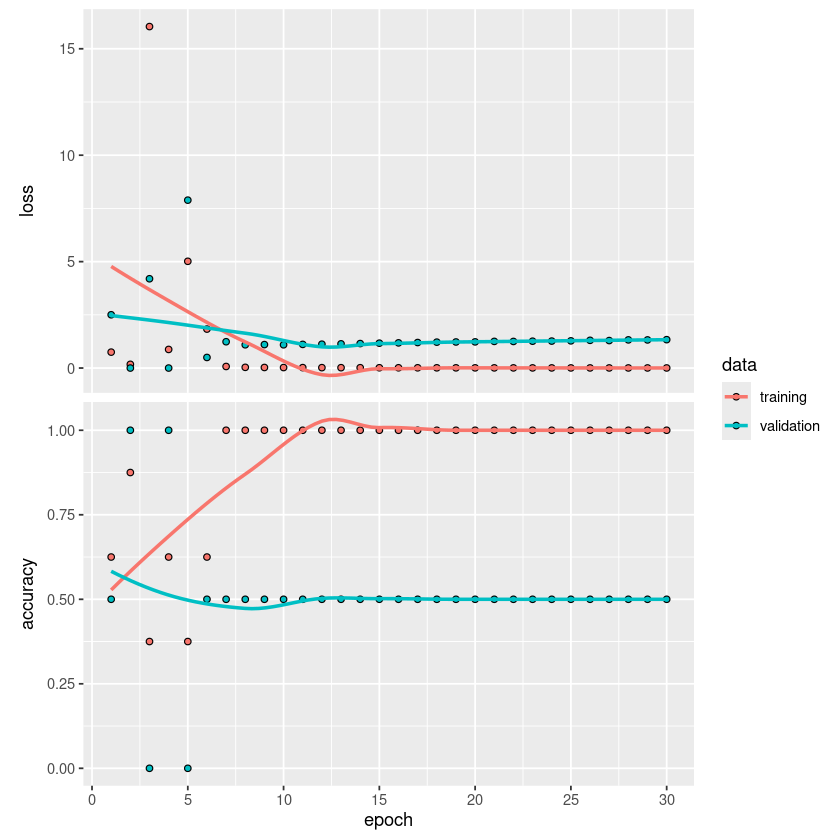

In [ ]:
# ============================================
# FULL SETUP + PIPELINE (Colab, R runtime)
# ============================================

# ---- 1. System dependencies for EBImage ----
system("apt-get update -y")
system("apt-get install -y libfftw3-dev libtiff5-dev libmagick++-dev python3-venv python3-pip python3-dev")

# ---- 2. Install EBImage ----
install.packages("BiocManager")
BiocManager::install("EBImage", update = FALSE, ask = FALSE)

# ---- 3. Python/TensorFlow/Keras setup (new reticulate style) ----
library(reticulate)
py_require("tensorflow")
py_require_legacy_keras()

library(tensorflow)
library(keras)
tf_config()   # sanity check — should show TF found, no error

library(EBImage)

# ---- 4. Unzip your data ----
system("unzip -o '/content/drive-download-20260902T060632Z-1-001.zip' -d /content/data")
list.files("/content/data", recursive = TRUE)   # confirm files landed here

setwd('/content/data')

# ---- 5. Load images ----
pics <- c('p1.jpg','p2.jpg','p3.jpg','p4.jpg','p5.jpg','p6.jpg',
          'c1.jpg','c2.jpg','c3.jpg','c4.jpg','c5.jpg','c6.jpg')

mypic <- list()
for (i in 1:12) { mypic[[i]] <- readImage(pics[i]) }

# ---- 6. Resize ----
for (i in 1:12) { mypic[[i]] <- resize(mypic[[i]], 28, 28) }

# ---- 7. Reshape ----
for (i in 1:12) { mypic[[i]] <- array_reshape(mypic[[i]], c(28, 28, 3)) }

# ---- 8. Train/test split ----
trainx <- NULL
for (i in c(1:5, 7:11)) { trainx <- rbind(trainx, mypic[[i]]) }

testx <- rbind(mypic[[6]], mypic[[12]])

trainy <- c(0,0,0,0,0, 1,1,1,1,1)
testy  <- c(0, 1)

# ---- 9. One-hot encode (manual, avoids to_categorical arg-name bug) ----
to_onehot <- function(y, num_classes = 2) {
  m <- matrix(0, nrow = length(y), ncol = num_classes)
  for (i in seq_along(y)) m[i, y[i] + 1] <- 1
  m
}

trainLabels <- to_onehot(trainy)
testLabels  <- to_onehot(testy)

# ---- 10. Build model ----
model <- keras_model_sequential()
model %>%
  layer_dense(units = 256, activation = 'relu', input_shape = c(2352)) %>%
  layer_dense(units = 128, activation = 'relu') %>%
  layer_dense(units = 2, activation = 'softmax')
summary(model)

# ---- 11. Compile ----
model %>% compile(
  loss = 'categorical_crossentropy',
  optimizer = optimizer_rmsprop(),
  metrics = c('accuracy')
)

# ---- 12. Fit ----
history <- model %>% fit(
  trainx, trainLabels,
  epochs = 30,
  batch_size = 32,
  validation_split = 0.2
)
plot(history)

# ---- 13. Evaluate: train ----
model %>% evaluate(trainx, trainLabels)
pred_prob <- model %>% predict(trainx)
pred <- apply(pred_prob, 1, which.max) - 1
table(Predicted = pred, Actual = trainy)

# ---- 14. Evaluate: test ----
model %>% evaluate(testx, testLabels)
test_pred_prob <- model %>% predict(testx)
test_pred <- apply(test_pred_prob, 1, which.max) - 1
table(Predicted = test_pred, Actual = testy)

In [ ]:
new_img <- readImage("/content/airplane.jpeg")
new_img <- resize(new_img, 28, 28)
new_img <- array_reshape(new_img, c(1, 2352))

pred_prob <- model %>% predict(new_img)
pred_class <- apply(pred_prob, 1, which.max) - 1

pred_prob     # [plane_prob, car_prob]
pred_class    # 0 = plane, 1 = car

0.9947503,0.005249657


[1] 0

In [ ]:
class_labels <- c("plane", "car")   # index 0 -> plane, index 1 -> car

pred_prob <- model %>% predict(new_img)
pred_class <- apply(pred_prob, 1, which.max) - 1
pred_name <- class_labels[pred_class + 1]

pred_prob
pred_name    # prints "plane" or "car"

0.9947503,0.005249657


[1] "plane"